# 문서 EDA
- 문서 탐색을 통해 전처리, 청킹, 리트리버 최적화 전략을 세웁니다.

In [1]:
# 필요한 라이브러리 임포트
import os
from langchain_community.document_loaders import PyMuPDFLoader
import matplotlib.pyplot as plt
from matplotlib import font_manager

# macOS 한글 폰트
plt.rcParams["font.family"] = "AppleGothic"
# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

# (선택) 실제 적용 확인
print(font_manager.findfont("AppleGothic"))


/Users/apple/anaconda3/envs/Team2-RAG-Project/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/System/Library/Fonts/Supplemental/AppleGothic.ttf


In [2]:
# 파일 로드
pdf_dir = '/Users/apple/Team2-RAG-Project/data/pdfs'
pdf_files = sorted([f for f in os.listdir(pdf_dir)])
docs = []
for file_name in pdf_files:
    loader = PyMuPDFLoader(os.path.join(pdf_dir, file_name))
    docs.extend(loader.load())

MuPDF error: syntax error: invalid key in dict

MuPDF error: syntax error: invalid key in dict



## 1. 메타데이터 확인
- 파일 고유의 메타데이터를 확인합니다.
- data_list.csv 메타데이터와의 매칭을 확인합니다.

In [3]:
# 보존해야할 지 확인.
import os
from langchain_community.document_loaders import PyMuPDFLoader

pdf_dir = "/Users/apple/Team2-RAG-Project/data/pdfs"
pdf_files = sorted([f for f in os.listdir(pdf_dir) if f.lower().endswith(".pdf")])

# 하나만 예시로 로드
sample_path = os.path.join(pdf_dir, pdf_files[0])
loader = PyMuPDFLoader(sample_path)
docs = loader.load()

print("샘플 파일:", pdf_files[0])
print("첫 번째 Document metadata:")
for k, v in docs[0].metadata.items():
    print(f"- {k}: {v}")


샘플 파일: (사)벤처기업협회_2024년 벤처확인종합관리시스템 기능 고도화 용역사업 .pdf
첫 번째 Document metadata:
- producer: Hancom PDF 1.3.0.547
- creator: Hwp 2024 13.0.0.1053
- creationdate: 2026-02-05T13:12:16+09:00
- source: /Users/apple/Team2-RAG-Project/data/pdfs/(사)벤처기업협회_2024년 벤처확인종합관리시스템 기능 고도화 용역사업 .pdf
- file_path: /Users/apple/Team2-RAG-Project/data/pdfs/(사)벤처기업협회_2024년 벤처확인종합관리시스템 기능 고도화 용역사업 .pdf
- total_pages: 131
- format: PDF 1.6
- title: 
- author: 김자주
- subject: 
- keywords: 
- moddate: 2026-02-05T13:12:16+09:00
- trapped: 
- modDate: D:20260205131216+09'00'
- creationDate: D:20260205131216+09'00'
- page: 0


author, page는 보존해서 나중에 메타데이터 결합 때 함께 결합 가능하다.

In [4]:
import os
import unicodedata
from pathlib import Path
import pandas as pd

# 경로 설정
csv_path = Path("/Users/apple/Team2-RAG-Project/data/raw/data_list.csv")
data_dir = Path("/Users/apple/Team2-RAG-Project/data/pdfs")   # parsed와 비교하려면 data/parsed로 변경

# 파일명 정규화 (확장자 제거 + 경로 제거 + 유니코드 정규화)
def norm_name(x):
    x = str(x).strip()
    x = os.path.basename(x)
    x = unicodedata.normalize("NFC", x)  # mac 파일명(NFD) 이슈 방지
    return Path(x).stem.strip()

# CSV 로드
df = pd.read_csv(csv_path)

# 파일명 컬럼 자동 탐색
candidates = ["file_name", "filename", "파일명", "source", "path", "file", "문서명"]
name_col = next((c for c in candidates if c in df.columns), None)
if name_col is None:
    raise ValueError(f"파일명 컬럼을 찾지 못했습니다. 컬럼 목록: {list(df.columns)}")

# CSV 파일명 집합
csv_names = {norm_name(v) for v in df[name_col].dropna() if str(v).strip()}

# 실제 파일명 집합
target_exts = {".pdf"}  # parsed 비교면 {".jsonl"}로 변경
real_names = {
    norm_name(p.name)
    for p in data_dir.iterdir()
    if p.is_file() and p.suffix.lower() in target_exts
}

# 비교
matched = sorted(csv_names & real_names)
missing_in_data = sorted(csv_names - real_names)  # CSV엔 있는데 파일 없음
extra_in_data = sorted(real_names - csv_names)    # 파일은 있는데 CSV엔 없음

# 출력
print(f"CSV 파일명 개수: {len(csv_names)}")
print(f"실데이터 파일명 개수: {len(real_names)}")
print(f"일치 개수: {len(matched)}")
print(f"CSV에만 있음(실데이터 없음): {len(missing_in_data)}")
print(f"실데이터에만 있음(CSV 없음): {len(extra_in_data)}")

print("\n[CSV에만 있는 파일명 샘플 10개]")
print(missing_in_data[:10])

print("\n[실데이터에만 있는 파일명 샘플 10개]")
print(extra_in_data[:10])

CSV 파일명 개수: 100
실데이터 파일명 개수: 100
일치 개수: 100
CSV에만 있음(실데이터 없음): 0
실데이터에만 있음(CSV 없음): 0

[CSV에만 있는 파일명 샘플 10개]
[]

[실데이터에만 있는 파일명 샘플 10개]
[]


모두 매칭된다.

## 2. 페이지, 문자 수 분포 확인
- chunk_size는 문자 수 기준으로 설정하므로 토큰 수가 아닌 문자 수 분포를 확인합니다.

In [5]:
# 1) 집계 테이블 만들기
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

parsed_dir = Path("/Users/apple/Team2-RAG-Project/data/parsed")

doc_rows = []
page_char_counts = []

for fp in sorted(parsed_dir.glob("*.jsonl")):
    doc_chars = 0
    page_cnt = 0

    with fp.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            row = json.loads(line)
            text = row.get("text") or row.get("page_content") or ""
            c = len(text)

            doc_chars += c
            page_cnt += 1
            page_char_counts.append(c)

    doc_rows.append({"file": fp.name, "pages": page_cnt, "chars": doc_chars})

df = pd.DataFrame(doc_rows).sort_values("chars", ascending=False).reset_index(drop=True)
page_s = pd.Series(page_char_counts, name="page_chars")


In [6]:
# 1. 전체 규모 값
print("=== 전체 규모 ===")
print(f"파일 수: {len(df)}")
print(f"전체 페이지 수: {int(df['pages'].sum()):,}")
print(f"전체 문자 수: {int(df['chars'].sum()):,}")

=== 전체 규모 ===
파일 수: 100
전체 페이지 수: 7,576
전체 문자 수: 7,508,315


In [7]:
# 2. 문서(파일) 단위 문자 수 통계
print("=== 문서(파일) 단위 문자 수 통계 ===")
display(df["chars"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).to_frame("value"))


=== 문서(파일) 단위 문자 수 통계 ===


,value
count,100.000000
mean,75083.150000
std,27462.730629
min,44107.000000
25%,55944.250000
50%,68368.500000
75%,82549.250000
90%,108263.600000
95%,118167.150000
max,232359.000000


In [8]:
# 3. 페이지 단위 문자 수 통계
print("=== 페이지 단위 문자 수 통계 ===")
display(page_s.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).to_frame("value"))


=== 페이지 단위 문자 수 통계 ===


,value
count,7576.000000
mean,991.065866
std,576.454165
min,0.000000
25%,625.000000
50%,884.500000
75%,1244.000000
90%,1798.500000
95%,2118.500000
max,4870.000000


In [9]:
# 4. 문자 수 기준 상/하위 파일
print("=== 문자 수 상위 10개 파일 ===")
display(df.nlargest(10, "chars")[["file", "pages", "chars"]])

print("=== 문자 수 하위 10개 파일 ===")
display(df.nsmallest(10, "chars")[["file", "pages", "chars"]])


=== 문자 수 상위 10개 파일 ===


,file,pages,chars
0,고려대학교_차세대 포털·학사 정보시스템 구...,297,232359
1,그랜드코리아레저(주)_2024년도 GKL 그룹웨어...,181,154550
2,KOICA 전자조달_[긴급] [지문] [국제] 우즈...,154,134830
3,한국철도공사 (용역)_모바일오피스 시스테...,181,132651
4,서울특별시_2024년 지도정보 플랫폼 및 ...,75,119899
5,울산광역시_2024년 버스정보시스템 확대 ...,129,118076
6,서울시립대학교_[사전공개] 학업성취도 ᄃ...,149,116224
7,재단법인경기도일자리재단_2025년 통합ᄌ...,137,113609
8,"서울특별시 여성가족재단_(재공고, 협상...",70,112886
9,한국농어촌공사_아세안+3 식량안보정보...,135,109538


=== 문자 수 하위 10개 파일 ===


,file,pages,chars
99,(재)예술경영지원센터_통합 정보시스템 ...,29,44107
98,한국원자력연구원_한국원자력연구원 ...,69,44805
97,기초과학연구원_2025년도 중이온가속기용...,49,45562
96,한국교육과정평가원_국가교육과정정보ᄉ...,32,47059
95,재단법인충북연구원_GIS통계 기반 재난...,64,47266
94,한영대학_한영대학교 특성화 맞춤형 ᄀ...,31,47745
93,조선대학교_(재공고)2024 조선대학교 SW중ᄉ...,52,47947
92,2025 구미 아시아육상경기선수권대회 조직ᄋ...,63,48155
91,대한적십자사 의료원_적십자병원 병원ᄌ...,71,48260
90,경희대학교_[입찰공고] 산학협력단 정...,48,48367


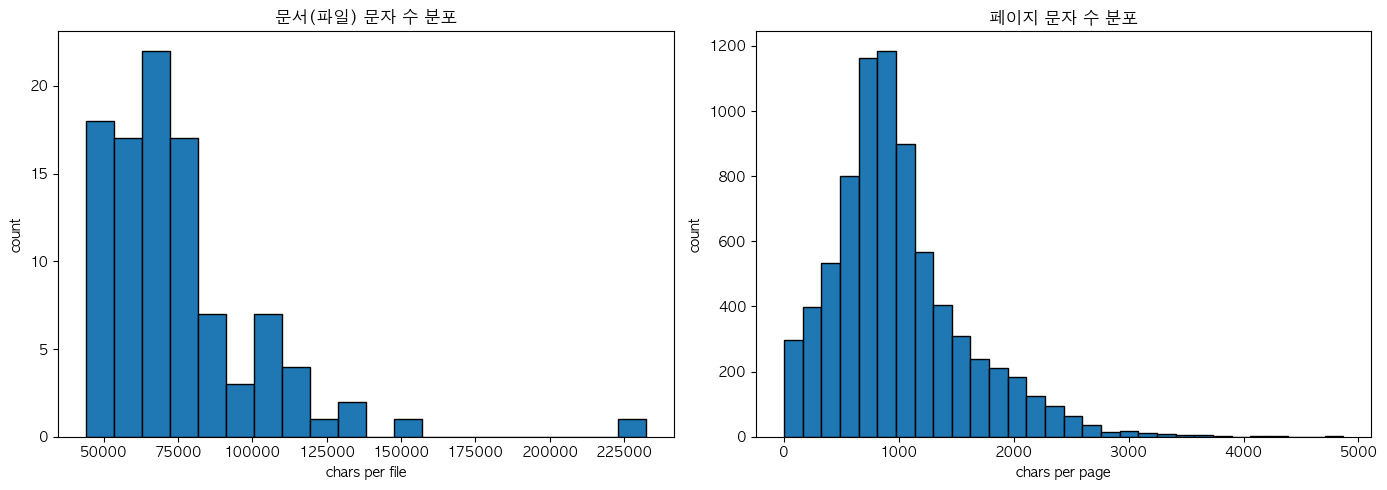

In [10]:
# 5. 문자 수 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["chars"], bins=20, edgecolor="black")
axes[0].set_title("문서(파일) 문자 수 분포")
axes[0].set_xlabel("chars per file")
axes[0].set_ylabel("count")

axes[1].hist(page_s, bins=30, edgecolor="black")
axes[1].set_title("페이지 문자 수 분포")
axes[1].set_xlabel("chars per page")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()


In [11]:
# 6. 파일 단위 페이지 수 통계
print("=== 파일 단위 페이지 수 통계 ===")
display(df["pages"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).to_frame("value"))


=== 파일 단위 페이지 수 통계 ===


,value
count,100.00000
mean,75.76000
std,41.02035
min,29.00000
25%,46.00000
50%,68.00000
75%,94.25000
90%,129.20000
95%,144.25000
max,297.00000


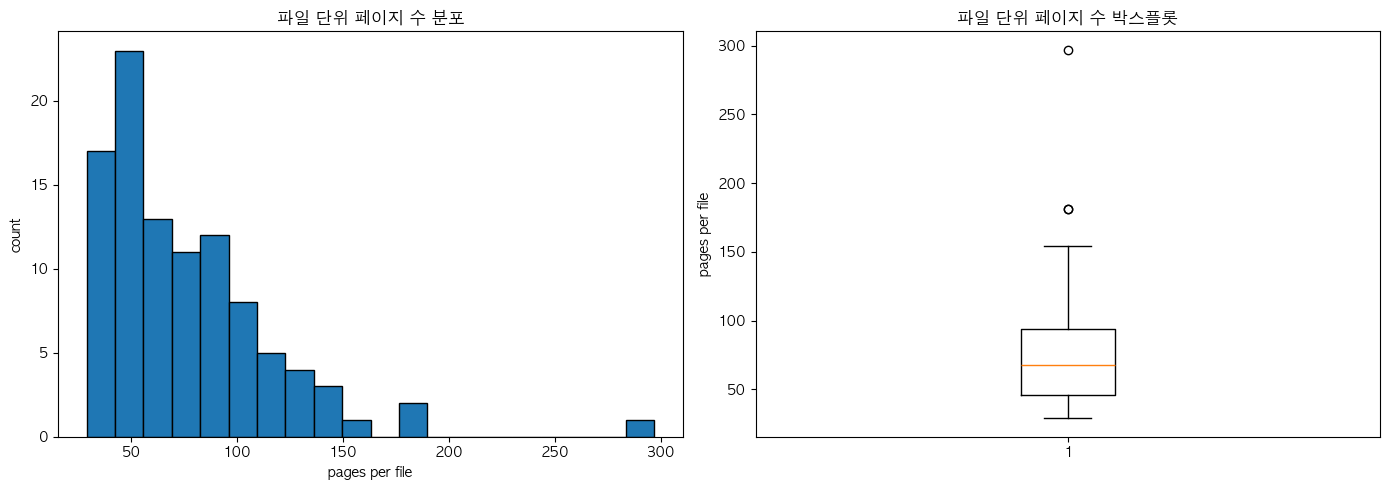

In [12]:
# 7. 페이지 수 분포 시각화
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(df["pages"], bins=20, edgecolor="black")
axes[0].set_title("파일 단위 페이지 수 분포")
axes[0].set_xlabel("pages per file")
axes[0].set_ylabel("count")

# 박스플롯
axes[1].boxplot(df["pages"], vert=True)
axes[1].set_title("파일 단위 페이지 수 박스플롯")
axes[1].set_ylabel("pages per file")

plt.tight_layout()
plt.show()


#### 페이지, 문자 수 분포 분석 결과

- **분석 대상**: `data/parsed/*.jsonl`  
- **파일 수**: `100개`  
- **총 페이지 수**: `7,576p`  
- **총 문자 수**: `7,471,741자`


##### 1) 파일 단위 페이지 수 
- 평균(75.76)이 중앙값(68)보다 높고 최대값(297)이 매우 커서, **우측 꼬리가 긴 분포**입니다.
- 즉, 일부 대형 문서가 전체 분포를 끌어올리는 구조입니다.


##### 2) 파일 단위 문자 수 
- 페이지 수와 유사하게 **우측 꼬리 분포**를 보입니다.
- 대다수 문서는 중간 구간에 밀집해 있고, 일부 초장문 문서가 상단 꼬리를 만듭니다.


##### 3) 페이지 단위 문자 수 
- 페이지 길이 편차가 큽니다. 페이지당 글자 수는 보통 878자 수준이지만,
짧은 쪽은 620자 이하, 긴 쪽은 1241자 이상으로 차이가 납니다.
- 최소값이 `0`인 페이지가 존재하므로, **빈 페이지 또는 파싱 추출 실패 페이지** 가능성이 있습니다.


##### 4) 결론

- 문서 길이는 전반적으로 장문(중앙값 68p)이며, 분포는 우측 꼬리가 긴 형태입니다.  
- 소수의 초장문 문서가 전체 텍스트 볼륨을 크게 좌우하므로, RAG 구성 시 문서 길이 불균형을 고려한 청킹/검색 전략이 필요합니다.  
- 또한 페이지 문자 수 0 사례에 대한 품질 점검(빈 페이지/파싱 누락 확인)이 필요합니다.

## 3. 문서당 표, 이미지 분포

In [13]:
# 라이브러리/경로 준비
from pathlib import Path
import fitz          # pymupdf
import pdfplumber
import pandas as pd
import matplotlib.pyplot as plt

pdf_dir = Path("/Users/apple/Team2-RAG-Project/data/pdfs")
pdf_files = sorted(pdf_dir.glob("*.pdf"))

print("PDF 파일 수:", len(pdf_files))


PDF 파일 수: 100


In [14]:
# 단계 0) 라이브러리 임포트
from tqdm.auto import tqdm
import fitz
import pandas as pd

# 단계 1) 처리 범위 설정
# - None이면 문서 전체 페이지 처리
# - 빠른 테스트용으로 50 같은 값 지정 가능
MAX_PAGES_PER_FILE = None

# 단계 2) 로고/아이콘 제외 기준(필요하면 조정)
MIN_IMG_AREA_RATIO = 0.01   # 페이지 면적의 1% 미만이면 로고/아이콘으로 간주
MIN_IMG_WIDTH = 120         # 표시 폭이 너무 작으면 제외
MIN_IMG_HEIGHT = 120        # 표시 높이가 너무 작으면 제외
LOGO_ASPECT_RATIO = 5.0     # 아주 납작/길쭉한 작은 이미지는 로고로 간주

def is_logo_like(rect, page_rect):
    """이미지 표시 영역(rect)이 로고/아이콘에 가까운지 판단"""
    w, h = rect.width, rect.height
    if w <= 0 or h <= 0:
        return True

    img_area = w * h
    page_area = max(page_rect.width * page_rect.height, 1)
    area_ratio = img_area / page_area
    aspect = max(w / h, h / w)

    # 작은 면적, 작은 크기, 작은데 극단적인 종횡비 -> 로고/아이콘으로 제외
    if area_ratio < MIN_IMG_AREA_RATIO:
        return True
    if w < MIN_IMG_WIDTH or h < MIN_IMG_HEIGHT:
        return True
    if area_ratio < 0.02 and aspect > LOGO_ASPECT_RATIO:
        return True

    return False

# 단계 3) 문서별 표/이미지 집계
rows = []

for fp in tqdm(pdf_files, desc="PDF 집계"):
    with fitz.open(fp) as doc:
        total_pages = len(doc)
        limit = total_pages if MAX_PAGES_PER_FILE is None else min(total_pages, MAX_PAGES_PER_FILE)

        image_count = 0      # 로고 제외 후 이미지 개수
        image_pages = 0      # 로고 제외 후 이미지가 있는 페이지 수
        table_count = 0
        table_pages = 0

        # 단계 4) 페이지 단위로 표/이미지 탐지
        for i in range(limit):
            page = doc[i]

            # 4-1) 이미지 탐지: 로고/아이콘 제외
            page_rect = page.rect
            raw_images = page.get_images(full=True)

            # 같은 이미지(xref) 중복 계산 방지
            xrefs = {img[0] for img in raw_images}
            non_logo_imgs_on_page = 0

            for xref in xrefs:
                rects = page.get_image_rects(xref)
                if not rects:
                    continue

                # 같은 xref가 여러 위치에 찍힌 경우 가장 큰 표시 영역 기준
                biggest_rect = max(rects, key=lambda r: r.width * r.height)

                if not is_logo_like(biggest_rect, page_rect):
                    non_logo_imgs_on_page += 1

            image_count += non_logo_imgs_on_page
            if non_logo_imgs_on_page > 0:
                image_pages += 1

            # 4-2) 표 탐지
            try:
                tf = page.find_tables()
                n_tbl = len(getattr(tf, "tables", []))
            except Exception:
                n_tbl = 0

            table_count += n_tbl
            if n_tbl > 0:
                table_pages += 1

    # 단계 5) 문서 단위 결과 저장
    rows.append({
        "file": fp.name,
        "total_pages": total_pages,
        "scanned_pages": limit,
        "table_pages": table_pages,
        "table_count": table_count,
        "image_pages": image_pages,   # 로고 제외 기준
        "image_count": image_count,   # 로고 제외 기준
    })

# 단계 6) 결과 테이블 생성
df = pd.DataFrame(rows)
df.head()



PDF 집계:   0%|          | 0/100 [00:00<?, ?it/s]

Consider using the pymupdf_layout package for a greatly improved page layout analysis.


PDF 집계:  41%|████      | 41/100 [03:22<06:01,  6.13s/it]

MuPDF error: syntax error: invalid key in dict

MuPDF error: syntax error: invalid key in dict



PDF 집계:  76%|███████▌  | 76/100 [06:28<02:02,  5.11s/it]


KeyboardInterrupt: 

In [ ]:
# 3. 비율 컬럼 추가
df["table_page_ratio"] = df["table_pages"] / df["total_pages"]
df["image_page_ratio"] = df["image_pages"] / df["total_pages"]

df[["file", "total_pages", "table_pages", "image_pages", "table_page_ratio", "image_page_ratio"]].head()


,file,total_pages,table_pages,image_pages,table_page_ratio,image_page_ratio
0,(사)벤처기업협회_2024년 벤처확인종합ᄀ...,131,96,6,0.732824,0.045802
1,(사)부산국제영화제_2024년 BIFF & ACFM 온ᄅ...,32,26,6,0.812500,0.187500
2,(사）한국대학스포츠협의회_KUSF 체육특기자...,40,36,7,0.900000,0.175000
3,(재)예술경영지원센터_통합 정보시스템 ...,29,23,2,0.793103,0.068966
4,2025 구미 아시아육상경기선수권대회 조직ᄋ...,63,45,1,0.714286,0.015873


In [ ]:
# 4. 전체 요약 출력
total_pages_all = int(df["total_pages"].sum())
table_pages_all = int(df["table_pages"].sum())
image_pages_all = int(df["image_pages"].sum())

print("=== 전체 요약 ===")
print(f"문서 수: {len(df)}")
print(f"총 페이지 수: {total_pages_all:,}")
print(f"표 포함 페이지 수: {table_pages_all:,} ({table_pages_all/total_pages_all:.2%})")
print(f"이미지 포함 페이지 수: {image_pages_all:,} ({image_pages_all/total_pages_all:.2%})")
print(f"총 표 개수: {int(df['table_count'].sum()):,}")
print(f"총 이미지 개수: {int(df['image_count'].sum()):,}")


=== 전체 요약 ===
문서 수: 100
총 페이지 수: 7,576
표 포함 페이지 수: 5,537 (73.09%)
이미지 포함 페이지 수: 276 (3.64%)
총 표 개수: 12,142
총 이미지 개수: 335


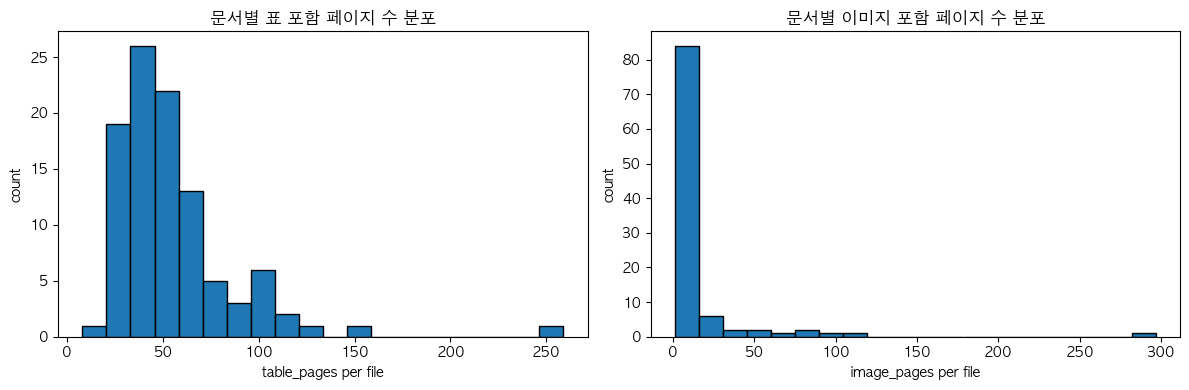

In [ ]:
# 5. 분포 그래프
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["table_pages"], bins=20, edgecolor="black")
axes[0].set_title("문서별 표 포함 페이지 수 분포")
axes[0].set_xlabel("table_pages per file")
axes[0].set_ylabel("count")

axes[1].hist(df["image_pages"], bins=20, edgecolor="black")
axes[1].set_title("문서별 이미지 포함 페이지 수 분포")
axes[1].set_xlabel("image_pages per file")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()


In [15]:
# 표 포함 페이지 vs 표 미포함 페이지 파이차트
import matplotlib.pyplot as plt

table_pages_all = int(df["table_pages"].sum())
total_pages_all = int(df["total_pages"].sum())
no_table_pages_all = total_pages_all - table_pages_all

labels = ["표 포함 페이지", "표 미포함 페이지"]
sizes = [table_pages_all, no_table_pages_all]
colors = ["#5B8FF9", "#D9D9D9"]

def pct_with_count(pct):
    count = int(round(pct / 100 * total_pages_all))
    return f"{pct:.1f}%\n({count:,}p)"

plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    autopct=pct_with_count,
    startangle=90,
    counterclock=False,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1}
)
plt.title("표 포함/미포함 페이지 비율")
plt.axis("equal")
plt.show()

print(f"총 페이지 수: {total_pages_all:,}p")
print(f"표 포함 페이지: {table_pages_all:,}p")
print(f"표 미포함 페이지: {no_table_pages_all:,}p")


KeyError: 'table_pages'

## 4. 새로운 파싱 기반 통계 요약

In [ ]:
# 새로운 파싱 결과(텍스트+표+이미지) 기준 통계 직접 계산
import json
from pathlib import Path
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path("/Users/apple/Team2-RAG-Project")
PARSED_DIR = PROJECT_ROOT / "data" / "parsed"
TEXT_DIR = PARSED_DIR / "text"
TABLE_DIR = PARSED_DIR / "table"
IMAGE_DIR = PARSED_DIR / "image"
MERGED_DIR = PARSED_DIR / "merged"

def read_lengths(jsonl_dir: Path) -> pd.Series:
    lengths = []
    for fp in sorted(jsonl_dir.glob("*.jsonl")):
        with fp.open("r", encoding="utf-8") as f:
            for line in f:
                if not line.strip():
                    continue
                row = json.loads(line)
                text = row.get("text") or row.get("page_content") or ""
                lengths.append(len(text))
    return pd.Series(lengths, dtype="int64")

def summarize_series(s: pd.Series) -> dict:
    if s.empty:
        return {
            "레코드수": 0, "평균": 0, "중앙값": 0, "최소": 0, "최대": 0,
            "25%": 0, "75%": 0, "700자 이하 비율": "0.0%"
        }
    q = s.quantile([0.25, 0.5, 0.75])
    return {
        "레코드수": int(s.size),
        "평균": round(float(s.mean()), 1),
        "중앙값": round(float(q.loc[0.5]), 1),
        "최소": int(s.min()),
        "최대": int(s.max()),
        "25%": round(float(q.loc[0.25]), 1),
        "75%": round(float(q.loc[0.75]), 1),
        "700자 이하 비율": f"{(s.le(700).mean() * 100):.1f}%"
    }

# 1) 레코드(텍스트/표/이미지)별 문자 수 통계
record_rows = []
for label, d in [("텍스트", TEXT_DIR), ("표", TABLE_DIR), ("이미지", IMAGE_DIR)]:
    s = read_lengths(d)
    row = {"구분": label}
    row.update(summarize_series(s))
    record_rows.append(row)

record_stats = pd.DataFrame(record_rows)

print("=== 레코드당 문자 수 분포 ===")
display(record_stats)

# 2) 페이지당 문자 수 통계 (텍스트+표+이미지 합산)
page_sum = {}
for fp in sorted(MERGED_DIR.glob("*.jsonl")):
    with fp.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            row = json.loads(line)
            source_file = row.get("source_file")
            page = row.get("page")
            text = row.get("text") or row.get("page_content") or ""
            key = (source_file, page)
            page_sum[key] = page_sum.get(key, 0) + len(text)

page_s = pd.Series(list(page_sum.values()), dtype="int64")
page_q = page_s.quantile([0.25, 0.5, 0.75]) if not page_s.empty else pd.Series({0.25: 0, 0.5: 0, 0.75: 0})

page_stats = pd.DataFrame([{
    "페이지수": int(page_s.size),
    "평균": round(float(page_s.mean()), 1) if not page_s.empty else 0,
    "중앙값": round(float(page_q.loc[0.5]), 1),
    "최소": int(page_s.min()) if not page_s.empty else 0,
    "최대": int(page_s.max()) if not page_s.empty else 0,
    "25%": round(float(page_q.loc[0.25]), 1),
    "75%": round(float(page_q.loc[0.75]), 1),
}])

print("=== 페이지당 문자 수 (텍스트+표+이미지 합산) ===")
display(page_stats)

# 3) 텍스트-only 대비 증가율(직접 계산)
text_page_sum = {}
for fp in sorted(TEXT_DIR.glob("*.jsonl")):
    with fp.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            row = json.loads(line)
            key = (row.get("source_file"), row.get("page"))
            text = row.get("text") or row.get("page_content") or ""
            text_page_sum[key] = text_page_sum.get(key, 0) + len(text)

text_page_s = pd.Series(list(text_page_sum.values()), dtype="int64")
if not text_page_s.empty and not page_s.empty:
    inc = (page_s.mean() / text_page_s.mean() - 1) * 100
    print(f"인사이트: 텍스트 전용 평균 {text_page_s.mean():,.1f}자/페이지 -> 통합 파싱 평균 {page_s.mean():,.1f}자/페이지 ({inc:+.1f}%)")


=== 레코드당 문자 수 분포 ===


,구분,레코드수,평균,중앙값,최소,최대,25%,75%,700자 이하 비율
0,텍스트,7576,411.4,119.0,0,4780,18.0,689.0,75.5%
1,표,12971,414.5,331.0,17,4839,144.0,560.5,82.7%
2,이미지,2872,216.9,136.0,0,1449,65.0,267.0,95.1%


=== 페이지당 문자 수 (텍스트+표+이미지 합산) ===


,페이지수,평균,중앙값,최소,최대,25%,75%
0,7576,1203.2,1047.0,0,9136,735.0,1529.2


인사이트: 텍스트 전용 평균 411.4자/페이지 -> 통합 파싱 평균 1,203.2자/페이지 (+192.5%)
